In [1]:
import kagglehub
from ffxt import output
from mediapipe.tasks.python.genai.converter.pytorch_converter import torch
from xgboost.testing.interaction_constraints import training_accuracy

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 775M/775M [01:31<00:00, 8.84MB/s] 

Extracting files...


Path to dataset files: C:\Users\Shubham Anil Birari\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


# Image Preprocessing

In [4]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

# Load Dataset

In [5]:
import os

print("Dataset path:", path)
print("Files/folders:")

for item in os.listdir(path):
    print(item)

Dataset path: C:\Users\Shubham Anil Birari\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1
Files/folders:
PetImages


In [6]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Number of files:", len(files))
    print()

Folder: C:\Users\Shubham Anil Birari\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1
Subfolders: ['PetImages']
Number of files: 0

Folder: C:\Users\Shubham Anil Birari\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1\PetImages
Subfolders: ['Cat', 'Dog']
Number of files: 0

Folder: C:\Users\Shubham Anil Birari\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1\PetImages\Cat
Subfolders: []
Number of files: 12499

Folder: C:\Users\Shubham Anil Birari\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1\PetImages\Dog
Subfolders: []
Number of files: 12499



In [8]:
dataset_path = os.path.join(path, "PetImages")

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

In [9]:
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)
print("Total images:", len(dataset))

Classes: ['Cat', 'Dog']
Class mapping: {'Cat': 0, 'Dog': 1}
Total images: 24998


# Split Training & Validation Data

In [10]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))

Training images: 19998
Validation images: 5000


# Create DataLoaders

In [11]:
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

In [13]:
images, labels = next(iter(train_loader))

print("Image:", images.shape)
print("Labels:", labels.shape)

Image: torch.Size([32, 3, 128, 128])
Labels: torch.Size([32])


# Build the CNN

In [14]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # First Convolution
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 2nd Convolution

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 3rd convolution
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                128*16*16,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [17]:
# Loss Function

loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Train the model

In [19]:
epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = loss_fn(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs}.. "
        f"Train loss: {total_loss:.4f}.."
        f"Accuracy: {train_accuracy:.2f}% "
    )

C:\Python\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/5.. Train loss: 392.6541..Accuracy: 64.43% 
Epoch 2/5.. Train loss: 338.3504..Accuracy: 72.76% 
Epoch 3/5.. Train loss: 293.4346..Accuracy: 77.83% 
Epoch 4/5.. Train loss: 259.5641..Accuracy: 80.77% 
Epoch 5/5.. Train loss: 230.7629..Accuracy: 83.59% 


# Validation

In [20]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(labels.cpu().numpy())

# Calculate Metrics

In [21]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

print(f"Accuracy: {accuracy:.2f}% ")
print(f"Precision: {precision:.2f}% ")
print(f"Recall: {recall:.2f}% ")

print(classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes
))

Accuracy: 0.82% 
Precision: 0.84% 
Recall: 0.78% 
              precision    recall  f1-score   support

         Cat       0.80      0.85      0.82      2504
         Dog       0.84      0.78      0.81      2496

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.82      0.82      0.82      5000



In [22]:
cm = confusion_matrix(
    all_labels,
    all_predictions,
)

print(cm)

[[2135  369]
 [ 542 1954]]


# Visualize

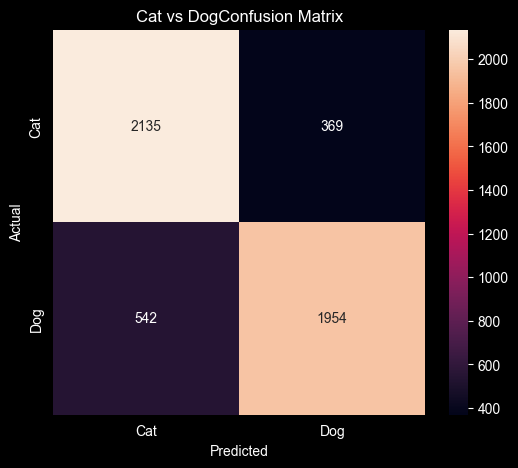

In [23]:
plt.figure(figsize=[6, 5])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cat vs DogConfusion Matrix")

plt.show()